# Mobile Phone Price Range Classification

## Business Problem
The goal of this project is to classify mobile phones into different **price ranges** (0: Low, 1: Medium, 2: High, 3: Very High) based on their hardware specifications. This is a multi-class classification problem that can help mobile phone companies estimate the price segment of a new phone based on its features.

## Approach
1. **Exploratory Data Analysis (EDA)** — Understand distributions, correlations, and outliers
2. **Data Cleaning** — Filter out unrealistic/invalid records
3. **Modeling** — Train and tune Decision Tree, Random Forest, and SVM classifiers
4. **Evaluation** — Compare models and select the best performer
5. **Prediction** — Apply the chosen model to unseen test data

## 1. Import Libraries
Import the necessary libraries for data manipulation, visualization, and machine learning.

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn import metrics
from sklearn.svm import SVC
from sklearn.preprocessing import MinMaxScaler
from sklearn.model_selection import GridSearchCV,train_test_split
from sklearn.pipeline import Pipeline
from types import SimpleNamespace
import warnings


In [2]:
warnings.filterwarnings('ignore')

## 2. Load the Dataset
Load the phone pricing dataset and take a first look at the data.

In [3]:
df = pd.read_csv('src/phone pricing.csv')
df

,battery_power,blue,clock_speed,dual_sim,fc,four_g,int_memory,m_dep,mobile_wt,n_cores,...,px_height,px_width,ram,sc_h,sc_w,talk_time,three_g,touch_screen,wifi,price_range
0,842,0,2.2,0,1,0,7,0.6,188,2,...,20,756,2549,9,7,19,0,0,1,1
1,1021,1,0.5,1,0,1,53,0.7,136,3,...,905,1988,2631,17,3,7,1,1,0,2
2,563,1,0.5,1,2,1,41,0.9,145,5,...,1263,1716,2603,11,2,9,1,1,0,2
3,615,1,2.5,0,0,0,10,0.8,131,6,...,1216,1786,2769,16,8,11,1,0,0,2
4,1821,1,1.2,0,13,1,44,0.6,141,2,...,1208,1212,1411,8,2,15,1,1,0,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1995,794,1,0.5,1,0,1,2,0.8,106,6,...,1222,1890,668,13,4,19,1,1,0,0
1996,1965,1,2.6,1,0,0,39,0.2,187,4,...,915,1965,2032,11,10,16,1,1,1,2
1997,1911,0,0.9,1,1,1,36,0.7,108,8,...,868,1632,3057,9,1,5,1,1,0,3
1998,1512,0,0.9,0,4,1,46,0.1,145,5,...,336,670,869,18,10,19,1,1,1,0


### Feature Description

| Feature | Description |
|---|---|
| `battery_power` | Total energy a battery can store (mAh) |
| `blue` | Has Bluetooth or not (0 = No, 1 = Yes) |
| `clock_speed` | Speed at which the microprocessor executes instructions (GHz) |
| `dual_sim` | Has dual SIM support or not (0 = No, 1 = Yes) |
| `fc` | Front camera megapixels |
| `four_g` | Has 4G support or not (0 = No, 1 = Yes) |
| `int_memory` | Internal memory (GB) |
| `m_dep` | Mobile depth (cm) |
| `mobile_wt` | Weight of the mobile phone (g) |
| `n_cores` | Number of processor cores |
| `pc` | Primary (rear) camera megapixels |
| `px_height` | Pixel resolution height |
| `px_width` | Pixel resolution width |
| `ram` | Random Access Memory (MB) |
| `sc_h` | Screen height (cm) |
| `sc_w` | Screen width (cm) |
| `talk_time` | Longest time a single battery charge will last during a call (hours) |
| `three_g` | Has 3G support or not (0 = No, 1 = Yes) |
| `touch_screen` | Has touch screen or not (0 = No, 1 = Yes) |
| `wifi` | Has WiFi or not (0 = No, 1 = Yes) |
| **`price_range`** | **Target variable** — Price class (0 = Low, 1 = Medium, 2 = High, 3 = Very High) |

## 3. Exploratory Data Analysis (EDA)

### 3.1 Data Overview
Inspect data types, summary statistics, missing values, and duplicates to understand the overall quality of the dataset.

In [4]:
print(df.info())
df.describe(include='all')

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2000 entries, 0 to 1999
Data columns (total 21 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   battery_power  2000 non-null   int64  
 1   blue           2000 non-null   int64  
 2   clock_speed    2000 non-null   float64
 3   dual_sim       2000 non-null   int64  
 4   fc             2000 non-null   int64  
 5   four_g         2000 non-null   int64  
 6   int_memory     2000 non-null   int64  
 7   m_dep          2000 non-null   float64
 8   mobile_wt      2000 non-null   int64  
 9   n_cores        2000 non-null   int64  
 10  pc             2000 non-null   int64  
 11  px_height      2000 non-null   int64  
 12  px_width       2000 non-null   int64  
 13  ram            2000 non-null   int64  
 14  sc_h           2000 non-null   int64  
 15  sc_w           2000 non-null   int64  
 16  talk_time      2000 non-null   int64  
 17  three_g        2000 non-null   int64  
 18  touch_sc

,battery_power,blue,clock_speed,dual_sim,fc,four_g,int_memory,m_dep,mobile_wt,n_cores,...,px_height,px_width,ram,sc_h,sc_w,talk_time,three_g,touch_screen,wifi,price_range
count,2000.000000,2000.0000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,...,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000
mean,1238.518500,0.4950,1.522250,0.509500,4.309500,0.521500,32.046500,0.501750,140.249000,4.520500,...,645.108000,1251.515500,2124.213000,12.306500,5.767000,11.011000,0.761500,0.503000,0.507000,1.500000
std,439.418206,0.5001,0.816004,0.500035,4.341444,0.499662,18.145715,0.288416,35.399655,2.287837,...,443.780811,432.199447,1084.732044,4.213245,4.356398,5.463955,0.426273,0.500116,0.500076,1.118314
min,501.000000,0.0000,0.500000,0.000000,0.000000,0.000000,2.000000,0.100000,80.000000,1.000000,...,0.000000,500.000000,256.000000,5.000000,0.000000,2.000000,0.000000,0.000000,0.000000,0.000000
25%,851.750000,0.0000,0.700000,0.000000,1.000000,0.000000,16.000000,0.200000,109.000000,3.000000,...,282.750000,874.750000,1207.500000,9.000000,2.000000,6.000000,1.000000,0.000000,0.000000,0.750000
50%,1226.000000,0.0000,1.500000,1.000000,3.000000,1.000000,32.000000,0.500000,141.000000,4.000000,...,564.000000,1247.000000,2146.500000,12.000000,5.000000,11.000000,1.000000,1.000000,1.000000,1.500000
75%,1615.250000,1.0000,2.200000,1.000000,7.000000,1.000000,48.000000,0.800000,170.000000,7.000000,...,947.250000,1633.000000,3064.500000,16.000000,9.000000,16.000000,1.000000,1.000000,1.000000,2.250000
max,1998.000000,1.0000,3.000000,1.000000,19.000000,1.000000,64.000000,1.000000,200.000000,8.000000,...,1960.000000,1998.000000,3998.000000,19.000000,18.000000,20.000000,1.000000,1.000000,1.000000,3.000000


In [5]:
def describe_values(df):

    variable = []
    unique = []
    count = []
    missing_values = []
    duplicate = []
    

    for col in df.columns:
        variable.append(col)
        count.append(df[col].count())
        unique.append(len(df[col].unique()))
        missing_values.append(df[col].isna().sum())
        duplicate.append(df[col].duplicated().sum())

    return(pd.DataFrame({
        'variables' : variable,
        'count' : count,
        'unique' : unique,
        'missing_values': missing_values,
        'duplicate': duplicate
    }
    ))

describe_values(df)

,variables,count,unique,missing_values,duplicate
0,battery_power,2000,1094,0,906
1,blue,2000,2,0,1998
2,clock_speed,2000,26,0,1974
3,dual_sim,2000,2,0,1998
4,fc,2000,20,0,1980
5,four_g,2000,2,0,1998
6,int_memory,2000,63,0,1937
7,m_dep,2000,10,0,1990
8,mobile_wt,2000,121,0,1879
9,n_cores,2000,8,0,1992


In [6]:
print(f'Number of duplicated rows : {df.duplicated().sum()}')

Number of duplicated rows : 0


**No duplicate rows** were found in the dataset, so no deduplication is needed.

In [7]:
df.corr()

,battery_power,blue,clock_speed,dual_sim,fc,four_g,int_memory,m_dep,mobile_wt,n_cores,...,px_height,px_width,ram,sc_h,sc_w,talk_time,three_g,touch_screen,wifi,price_range
battery_power,1.000000,0.011252,0.011482,-0.041847,0.033334,0.015665,-0.004004,0.034085,0.001844,-0.029727,...,0.014901,-0.008402,-0.000653,-0.029959,-0.021421,0.052510,0.011522,-0.010516,-0.008343,0.200723
blue,0.011252,1.000000,0.021419,0.035198,0.003593,0.013443,0.041177,0.004049,-0.008605,0.036161,...,-0.006872,-0.041533,0.026351,-0.002952,0.000613,0.013934,-0.030236,0.010061,-0.021863,0.020573
clock_speed,0.011482,0.021419,1.000000,-0.001315,-0.000434,-0.043073,0.006545,-0.014364,0.012350,-0.005724,...,-0.014523,-0.009476,0.003443,-0.029078,-0.007378,-0.011432,-0.046433,0.019756,-0.024471,-0.006606
dual_sim,-0.041847,0.035198,-0.001315,1.000000,-0.029123,0.003187,-0.015679,-0.022142,-0.008979,-0.024658,...,-0.020875,0.014291,0.041072,-0.011949,-0.016666,-0.039404,-0.014008,-0.017117,0.022740,0.017444
fc,0.033334,0.003593,-0.000434,-0.029123,1.000000,-0.016560,-0.029133,-0.001791,0.023618,-0.013356,...,-0.009990,-0.005176,0.015099,-0.011014,-0.012373,-0.006829,0.001793,-0.014828,0.020085,0.021998
four_g,0.015665,0.013443,-0.043073,0.003187,-0.016560,1.000000,0.008690,-0.001823,-0.016537,-0.029706,...,-0.019236,0.007448,0.007313,0.027166,0.037005,-0.046628,0.584246,0.016758,-0.017620,0.014772
int_memory,-0.004004,0.041177,0.006545,-0.015679,-0.029133,0.008690,1.000000,0.006886,-0.034214,-0.028310,...,0.010441,-0.008335,0.032813,0.037771,0.011731,-0.002790,-0.009366,-0.026999,0.006993,0.044435
m_dep,0.034085,0.004049,-0.014364,-0.022142,-0.001791,-0.001823,0.006886,1.000000,0.021756,-0.003504,...,0.025263,0.023566,-0.009434,-0.025348,-0.018388,0.017003,-0.012065,-0.002638,-0.028353,0.000853
mobile_wt,0.001844,-0.008605,0.012350,-0.008979,0.023618,-0.016537,-0.034214,0.021756,1.000000,-0.018989,...,0.000939,0.000090,-0.002581,-0.033855,-0.020761,0.006209,0.001551,-0.014368,-0.000409,-0.030302
n_cores,-0.029727,0.036161,-0.005724,-0.024658,-0.013356,-0.029706,-0.028310,-0.003504,-0.018989,1.000000,...,-0.006872,0.024480,0.004868,-0.000315,0.025826,0.013148,-0.014733,0.023774,-0.009964,0.004399


### 3.2 Correlation Analysis
Compute the correlation matrix and visualize it as a heatmap to identify which features are most strongly related to the target variable (`price_range`).

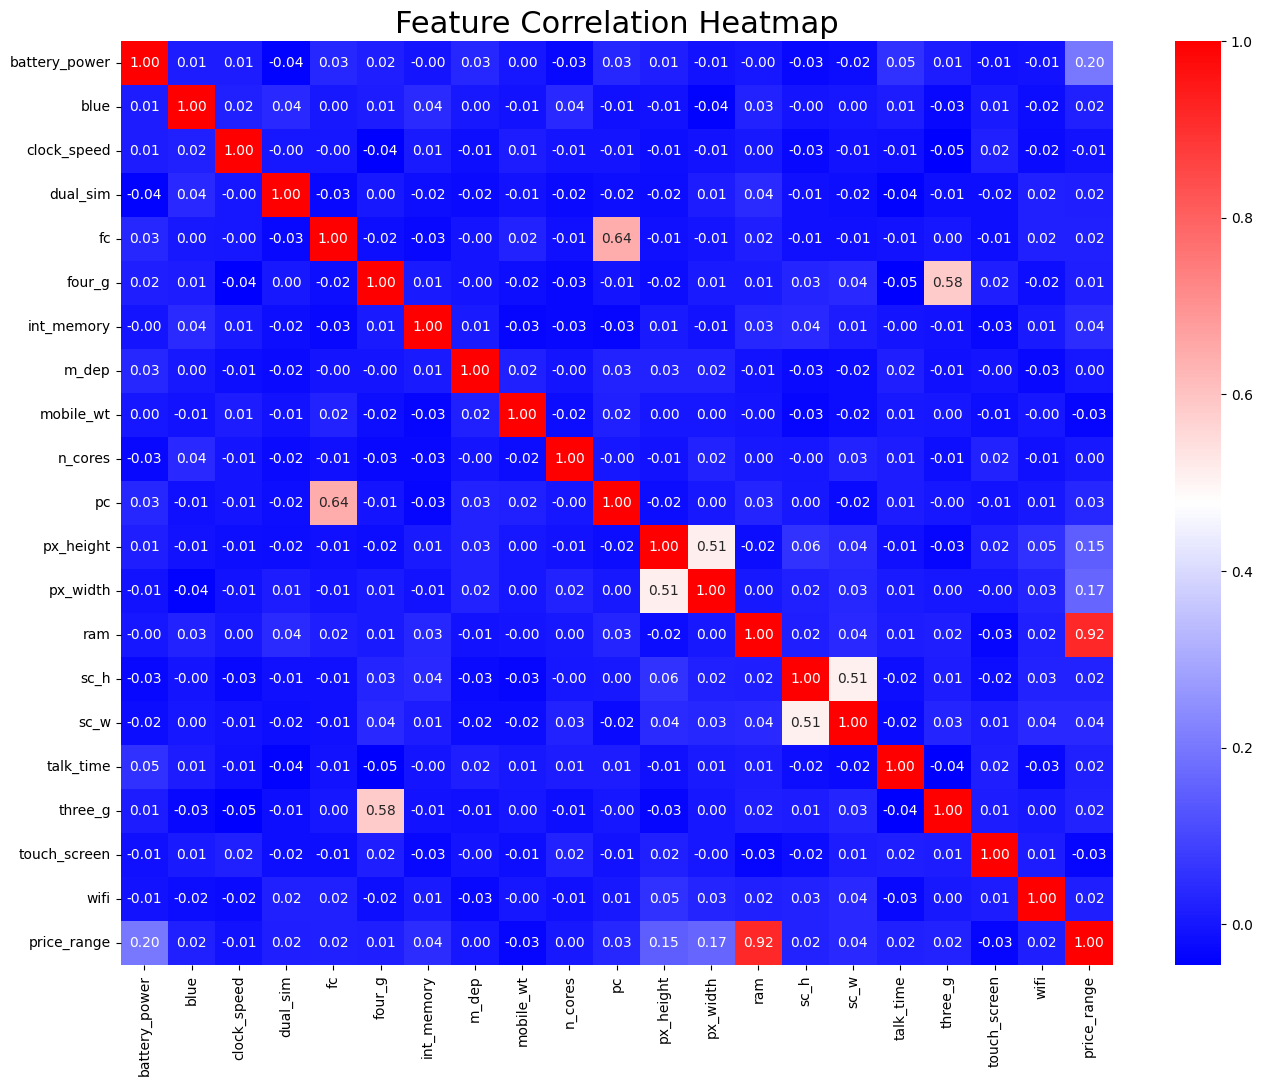

In [8]:
plt.figure(figsize=[16,12])
sns.heatmap(df.corr(), cmap ='bwr',cbar=True,annot=True,fmt='.2f')
plt.title('Feature Correlation Heatmap', fontsize=22)
plt.show()

- **RAM** has the strongest positive correlation with `price_range` (~0.92), making it by far the most important predictor of phone price.
- **Battery power**, **pixel height**, and **pixel width** also show moderate positive correlations with price.
- Features like `blue`, `dual_sim`, `four_g`, `three_g`, and `touch_screen` show very weak correlation with price — these binary features alone are not strong price drivers.
- There is notable correlation between `px_height` and `px_width`, and between `sc_h` and `sc_w`, which is expected since screen/pixel dimensions tend to scale together.
- No strong negative correlations exist anywhere in the dataset.

In [9]:
df.columns

Index(['battery_power', 'blue', 'clock_speed', 'dual_sim', 'fc', 'four_g',
       'int_memory', 'm_dep', 'mobile_wt', 'n_cores', 'pc', 'px_height',
       'px_width', 'ram', 'sc_h', 'sc_w', 'talk_time', 'three_g',
       'touch_screen', 'wifi', 'price_range'],
      dtype='object')

### 3.3 Distribution of Categorical / Binary Features
Visualize the count distributions of binary and discrete features to check for class imbalance.

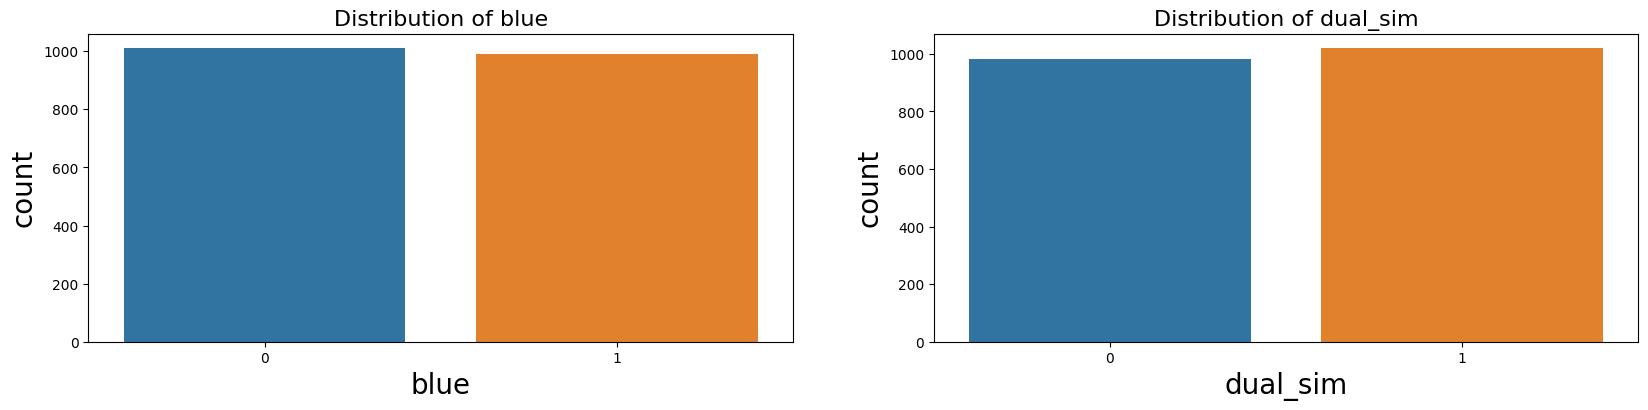

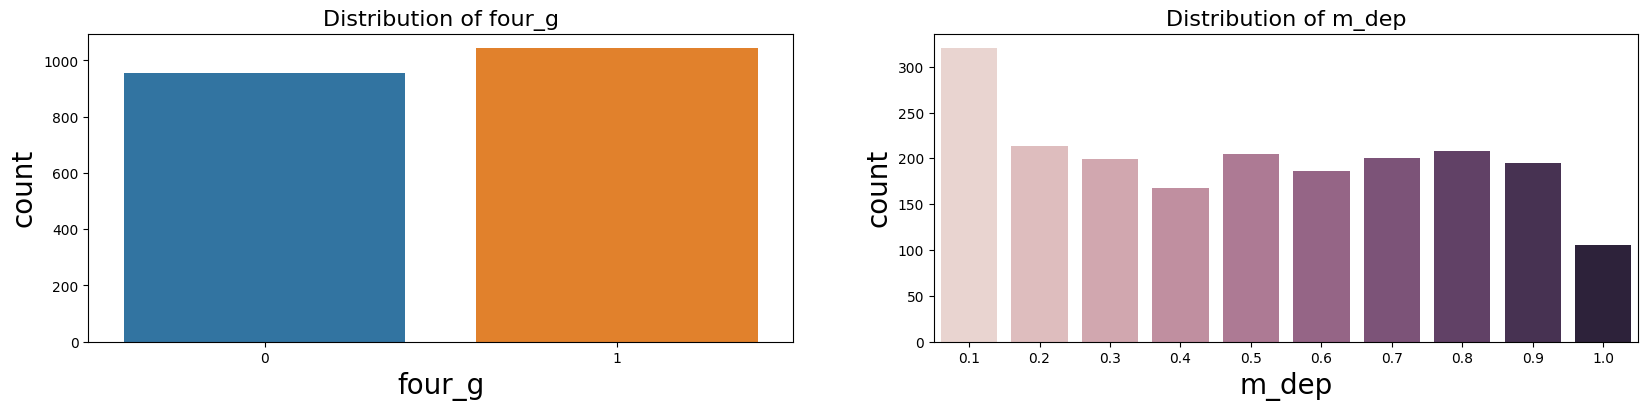

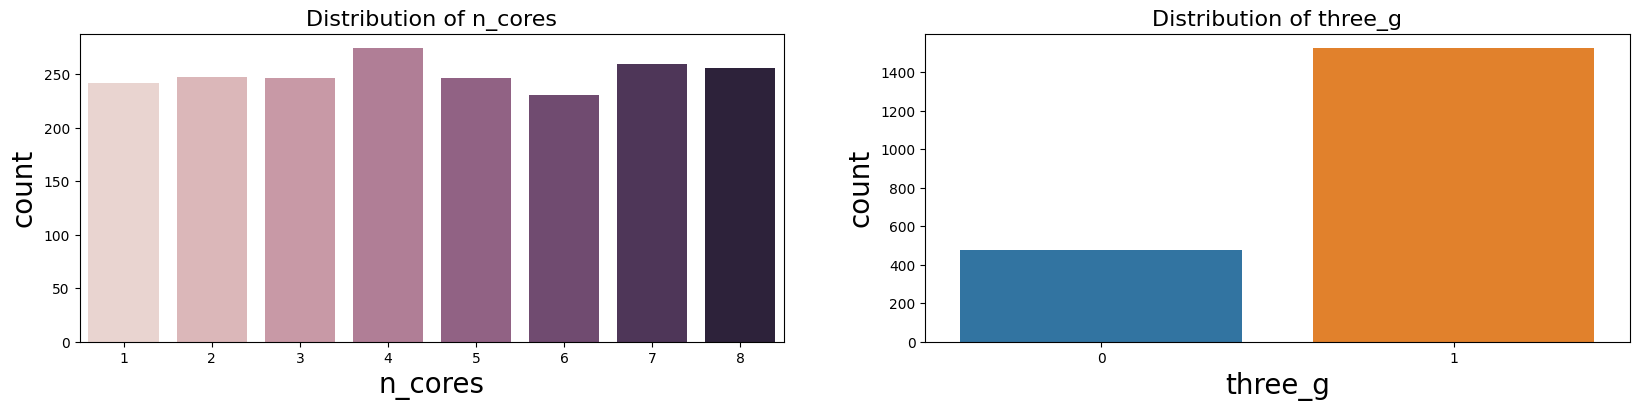

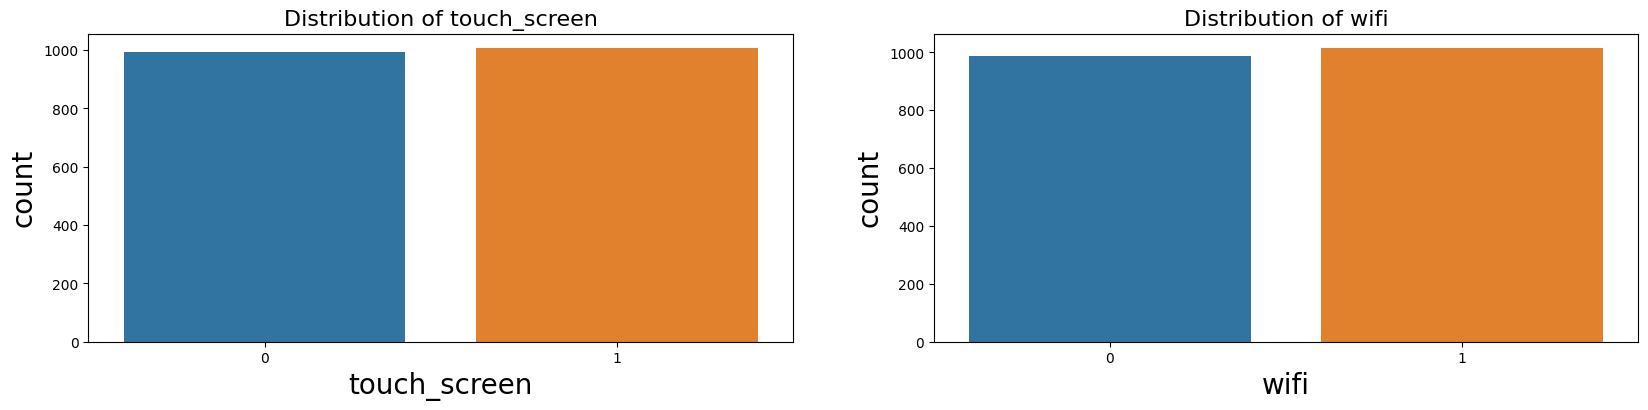

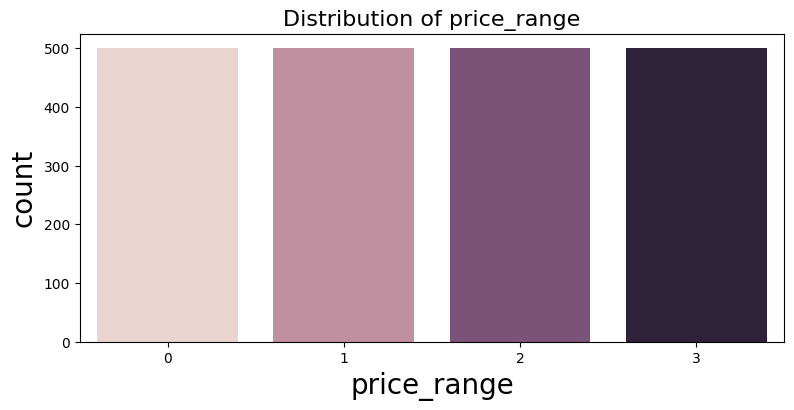

In [10]:
df_cplot = df[[
            'blue','dual_sim','four_g','m_dep','n_cores',
            'three_g','touch_screen','wifi','price_range'
            ]]
i = 1
plt.figure(figsize=[20,4])
for cat in df_cplot:
    plt.subplot(1,2,i)
    sns.countplot(data=df_cplot,x=cat, hue= cat, legend=False)
    plt.title(f'Distribution of {cat}', fontsize=16)
    plt.xlabel(cat, fontsize = 20)
    plt.ylabel('count', fontsize = 20)
    if i == 2:
        plt.show()
        i=0
        plt.figure(figsize=[20,4])
    i +=1

- Binary features (`blue`, `dual_sim`, `four_g`, `touch_screen`, `wifi`) are roughly balanced between 0 and 1, indicating no strong class imbalance.
- `three_g` is slightly skewed toward 1, meaning most phones in the dataset support 3G.
- `m_dep` (mobile depth) and `n_cores` (number of processor cores) are fairly uniformly distributed.
- The **target variable `price_range`** is evenly distributed across all four classes (0–3), which is ideal for classification — no need for resampling techniques.

### 3.4 Distribution of Numerical Features (Box Plots)
Use box plots to examine the spread and detect outliers in continuous numerical features.

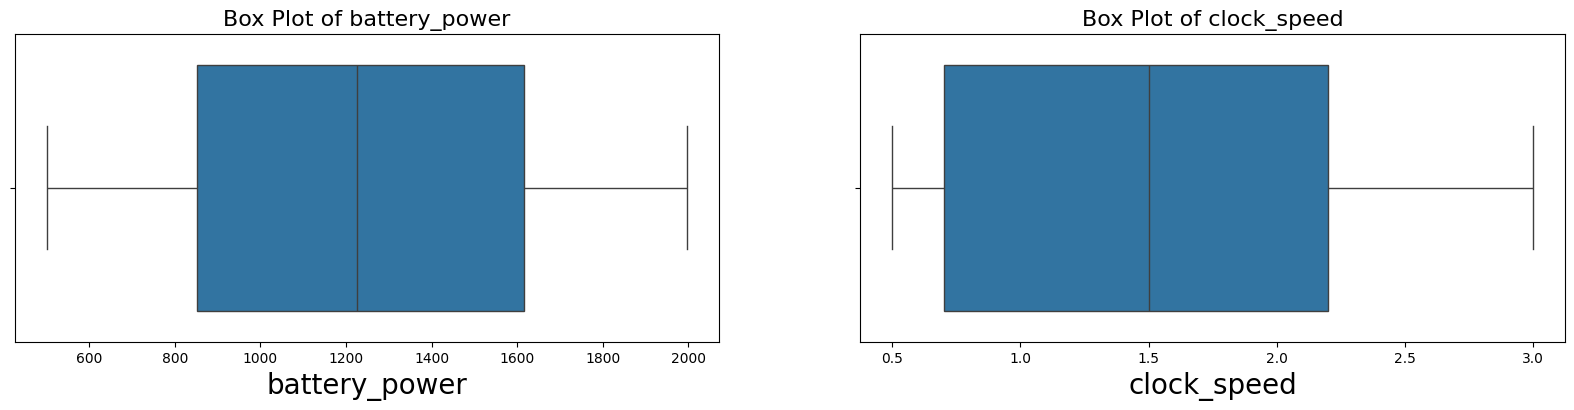

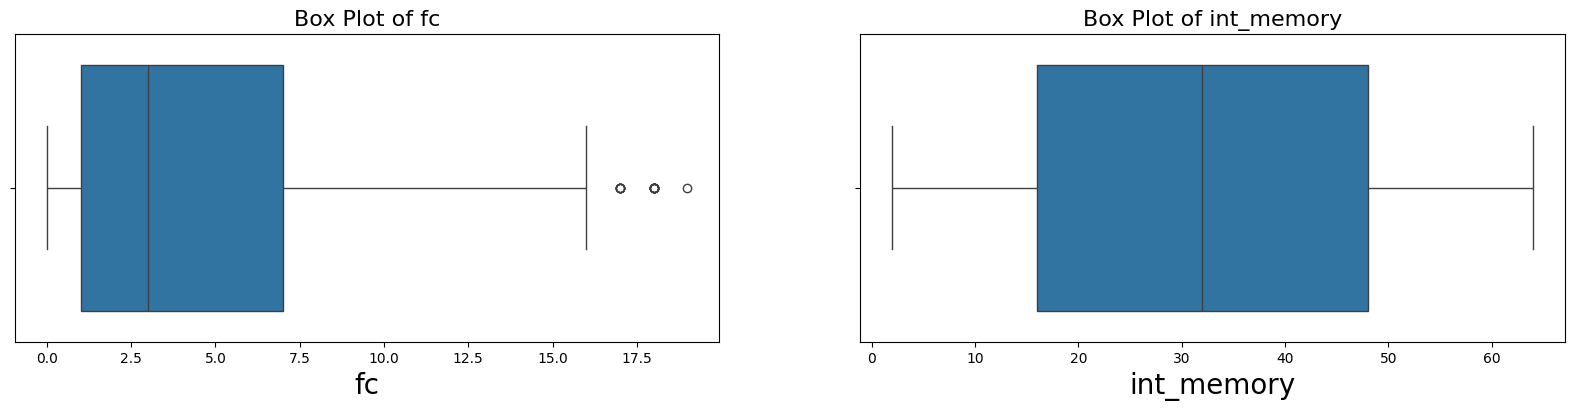

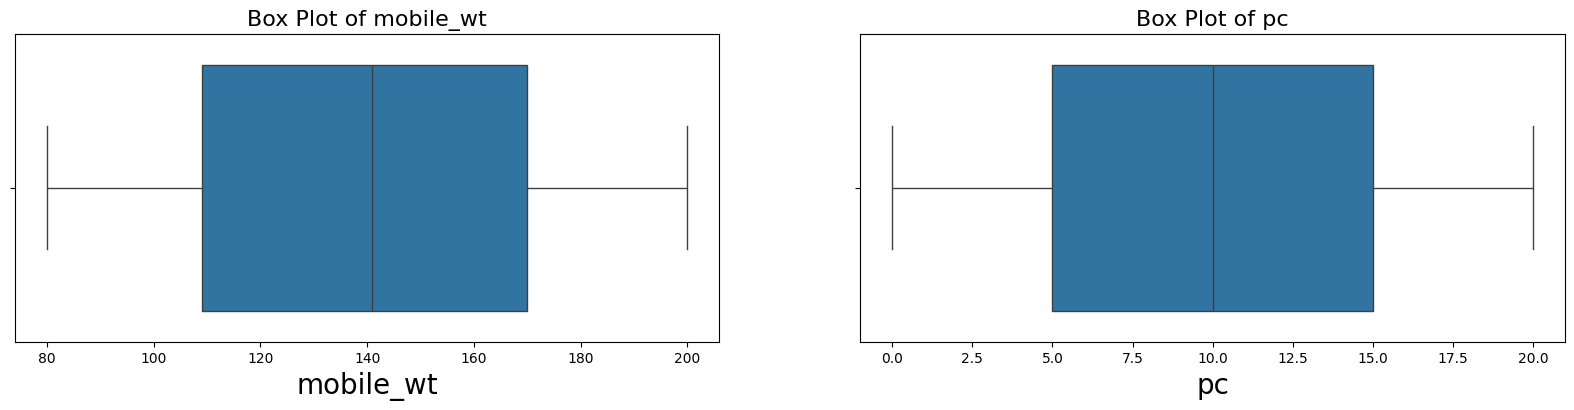

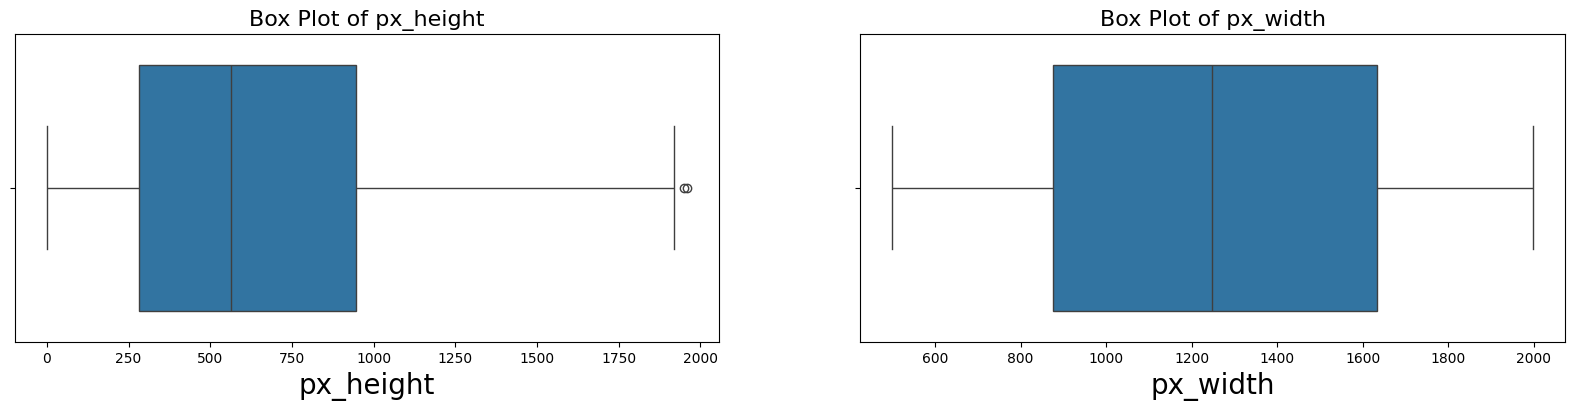

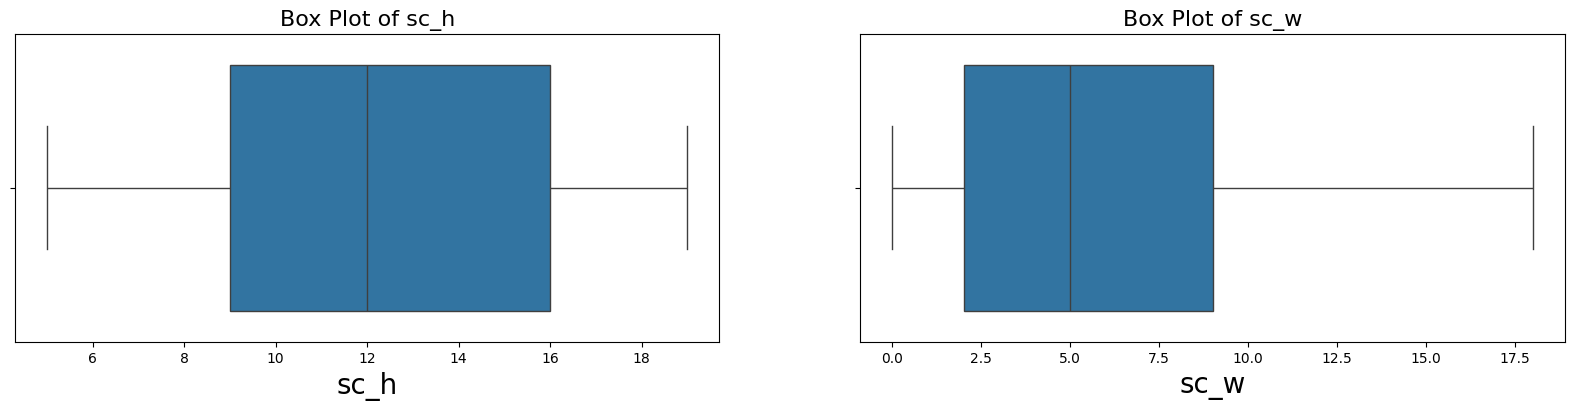

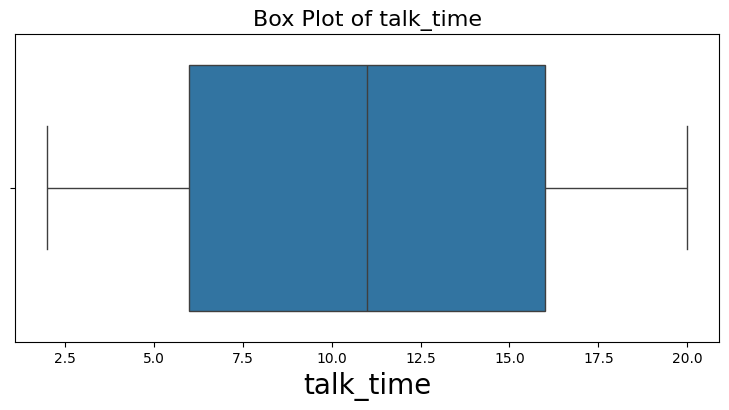

In [11]:
df_cplot = df[[
           'battery_power', 'clock_speed', 'fc',
       'int_memory', 'mobile_wt', 'pc', 'px_height',
       'px_width', 'sc_h', 'sc_w', 'talk_time'
            ]]
i = 1
plt.figure(figsize=[20,4])

for cat in df_cplot:
    plt.subplot(1,2,i)
    sns.boxplot(data=df_cplot,x = cat)
    plt.title(f'Box Plot of {cat}', fontsize=16)
    plt.xlabel(cat, fontsize = 20)
    if i == 2:
        plt.show()
        i=0
        plt.figure(figsize=[20,4])
    i+=1


- **`fc` (front camera)** has visible outliers on the higher end, but these are plausible for high-end phones.
- **`px_height`** has a wide range with some entries near 0, which are likely unrealistic values (a phone cannot have 0 pixel height).
- **`sc_w` (screen width)** also contains some very low values close to 0, flagging potential data quality issues.
- Features like `battery_power`, `int_memory`, `mobile_wt`, and `talk_time` appear to have reasonable distributions without extreme outliers.
- These observations suggest the need for data filtering to remove physically impossible records before modeling.

### 3.5 RAM vs Price Range
Scatter plot to examine the relationship between RAM and the target variable.

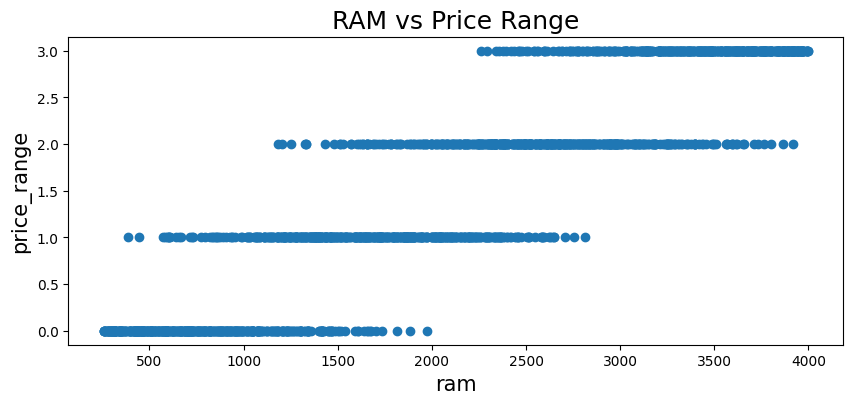

In [12]:
plt.figure(figsize=[10,4])
plt.scatter(x=df['ram'],y=df['price_range'])
plt.title('RAM vs Price Range', fontsize=18)
plt.xlabel('ram',fontsize = 15)
plt.ylabel('price_range',fontsize = 15)
plt.show()

- RAM shows a **clear linear separation** across price ranges. Phones with low RAM fall into price range 0, while phones with higher RAM fall into higher price ranges.
- This confirms the earlier correlation finding: RAM is the single most important feature for predicting phone price class.
- The boundaries between price groups are well-defined, which indicates this feature alone could achieve reasonable classification accuracy.

## 4. Data Cleaning — Filter Unrealistic Records
Based on the EDA, some records have physically impossible values (e.g., 0 pixel height, 0 screen width). We filter out rows where `m_dep`, `px_height`, `px_width`, `sc_h`, or `sc_w` fall below realistic thresholds.

In [13]:
df_real = df[(df['m_dep']> .2) 
            & (df['px_height']>96) 
            & (df['px_width']> 65)
            & (df['sc_h']> 2)
            & (df['sc_w']>= 2)] 
df_real

,battery_power,blue,clock_speed,dual_sim,fc,four_g,int_memory,m_dep,mobile_wt,n_cores,...,px_height,px_width,ram,sc_h,sc_w,talk_time,three_g,touch_screen,wifi,price_range
1,1021,1,0.5,1,0,1,53,0.7,136,3,...,905,1988,2631,17,3,7,1,1,0,2
2,563,1,0.5,1,2,1,41,0.9,145,5,...,1263,1716,2603,11,2,9,1,1,0,2
3,615,1,2.5,0,0,0,10,0.8,131,6,...,1216,1786,2769,16,8,11,1,0,0,2
4,1821,1,1.2,0,13,1,44,0.6,141,2,...,1208,1212,1411,8,2,15,1,1,0,1
6,1821,0,1.7,0,4,1,10,0.8,139,8,...,381,1018,3220,13,8,18,1,0,1,3
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1988,1547,1,2.9,0,2,0,57,0.4,114,1,...,347,957,1620,9,2,19,0,1,1,1
1990,1617,1,2.4,0,8,1,36,0.8,85,1,...,743,1426,296,5,3,7,1,0,0,0
1993,1467,1,0.5,0,0,0,18,0.6,122,5,...,888,1099,3962,15,11,5,1,1,1,3
1995,794,1,0.5,1,0,1,2,0.8,106,6,...,1222,1890,668,13,4,19,1,1,0,0


In [14]:
df.columns

Index(['battery_power', 'blue', 'clock_speed', 'dual_sim', 'fc', 'four_g',
       'int_memory', 'm_dep', 'mobile_wt', 'n_cores', 'pc', 'px_height',
       'px_width', 'ram', 'sc_h', 'sc_w', 'talk_time', 'three_g',
       'touch_screen', 'wifi', 'price_range'],
      dtype='object')

## 5. Model Preparation
Separate features (`X`) and target (`Y`), then define a reusable evaluation function for comparing classifiers.

In [15]:
X = df_real.drop('price_range',axis=1)
Y = df_real['price_range']


In [16]:
def evalutaion (model,y_test,y_pred):
    
    print(f'Classes:\n{model.classes_}')
    print(f'Classification report:\n{metrics.classification_report(y_test,y_pred)}')
    print(f'Confiussion matrix:\n{metrics.confusion_matrix(y_test,y_pred)}')


## 6. Decision Tree Classifier
Use `GridSearchCV` to find the optimal hyperparameters for a Decision Tree across multiple test sizes, then evaluate the best model.

In [17]:
def tuner(x_train,y_train,X_test):
    params = {
    'criterion' : ['gini','entropy'],
    'max_depth' : [3, 5, 7, None],
    'min_samples_leaf' : [1, 2, 4],
    'min_samples_split' : [2, 5, 10]
    }

    grid_dts = GridSearchCV(
        param_grid= params,
        estimator= DecisionTreeClassifier(random_state=42),
        cv = 5,
        scoring='accuracy',
        n_jobs= -1
    )

    grid_dts.fit(x_train,y_train.ravel())
    prediction = grid_dts.predict(X_test)
    

    return SimpleNamespace(
        best_params = grid_dts.best_params_,
        best_score = grid_dts.best_score_,
        best_model = grid_dts.best_estimator_,
        prediction= prediction
    
    )





In [18]:
test_size = [.1,.15,.2,.25]
best_score_finder = 0

for size in test_size:
    X_train,X_test,y_train,y_test = train_test_split(X,Y,test_size=size,random_state=42)
    best_tune = tuner(X_train,y_train,X_test)
    print (f'Test size: {size} and best params are:')
    print (best_tune.best_params)
    if best_score_finder < best_tune.best_score : 
        best_score_finder = best_tune.best_score
        best_model = best_tune.best_model
        best_size = size
        best_y_test = y_test
        y_pred = best_tune.prediction
        


Test size: 0.1 and best params are:
{'criterion': 'entropy', 'max_depth': 7, 'min_samples_leaf': 2, 'min_samples_split': 10}
Test size: 0.15 and best params are:
{'criterion': 'entropy', 'max_depth': None, 'min_samples_leaf': 4, 'min_samples_split': 2}
Test size: 0.2 and best params are:
{'criterion': 'entropy', 'max_depth': None, 'min_samples_leaf': 1, 'min_samples_split': 10}
Test size: 0.25 and best params are:
{'criterion': 'entropy', 'max_depth': None, 'min_samples_leaf': 2, 'min_samples_split': 2}


In [19]:
print(f'Best score:\n{best_score_finder}')
print(f'Best model:\n{best_model}')
print(f'Best size:\n{best_size}')

evalutaion(best_model,best_y_test,y_pred)


Best score:
0.8508454286996858
Best model:
DecisionTreeClassifier(criterion='entropy', min_samples_leaf=2, random_state=42)
Best size:
0.25
Classes:
[0 1 2 3]
Classification report:
              precision    recall  f1-score   support

           0       0.88      0.87      0.88        78
           1       0.65      0.68      0.67        60
           2       0.77      0.79      0.78        78
           3       0.92      0.84      0.88        57

    accuracy                           0.80       273
   macro avg       0.81      0.80      0.80       273
weighted avg       0.81      0.80      0.80       273

Confiussion matrix:
[[68 10  0  0]
 [ 9 41 10  0]
 [ 0 12 62  4]
 [ 0  0  9 48]]


**Decision Tree Results:**
- The Decision Tree achieves a reasonable accuracy but may struggle with some boundary cases between adjacent price ranges.
- Grid search finds the optimal combination of `criterion`, `max_depth`, `min_samples_leaf`, and `min_samples_split`.
- The best test size provides a balance between having enough training data and a reliable held-out evaluation set.

## 7. Random Forest Classifier
Train a Random Forest with `GridSearchCV` over a wide hyperparameter grid. Random Forest is an ensemble of Decision Trees and typically yields better generalization.

In [28]:
X_train, X_test, y_train, y_test = train_test_split(X, Y, test_size=.15, random_state=42)

param = {
    'n_estimators': [50, 100, 200],
    'bootstrap': [True, False],
    'max_depth': [None, 10, 20, 30],
    'min_samples_leaf': [1, 2, 4],
    'min_samples_split': [2, 5, 10],
    'max_features': ['sqrt', 'log2']
}


rf_grid = GridSearchCV(
    estimator=RandomForestClassifier(random_state=42),
    param_grid=param,
    cv=5,
    scoring='accuracy',
    n_jobs=-1
)

rf_grid.fit(X_train, y_train)
y_pred = rf_grid.predict(X_test)

print("Best Parameters:", rf_grid.best_params_)
print("Best CV Score:", rf_grid.best_score_)




Best Parameters: {'bootstrap': False, 'max_depth': 20, 'max_features': 'sqrt', 'min_samples_leaf': 1, 'min_samples_split': 2, 'n_estimators': 200}
Best CV Score: 0.8749084568439407


In [21]:
evalutaion(rf_grid.best_estimator_,y_test,y_pred)

Classes:
[0 1 2 3]
Classification report:
              precision    recall  f1-score   support

           0       0.93      0.87      0.90        45
           1       0.68      0.79      0.73        38
           2       0.82      0.77      0.80        48
           3       0.91      0.91      0.91        33

    accuracy                           0.83       164
   macro avg       0.84      0.83      0.83       164
weighted avg       0.84      0.83      0.83       164

Confiussion matrix:
[[39  6  0  0]
 [ 3 30  5  0]
 [ 0  8 37  3]
 [ 0  0  3 30]]


**Random Forest Results:**
- Random Forest generally outperforms a single Decision Tree due to ensemble averaging, which reduces variance and overfitting.
- The selected hyperparameters (number of estimators, max depth, etc.) control model complexity.
- Compare the classification report metrics (precision, recall, F1) per price class against the Decision Tree results above.

## 8. Support Vector Machine (SVM) Classifier
Train an SVM with `MinMaxScaler` in a pipeline. SVM benefits from feature scaling and can capture non-linear decision boundaries via the kernel trick. We tune `C`, `gamma`, `kernel`, and `degree` using `GridSearchCV`.

In [22]:
X_train, X_test, y_train, y_test = train_test_split(X, Y, test_size=.15, random_state=42)

param = {
    'svm__C': [0.1, 1, 10, 100],
    'svm__gamma': ['scale','auto'],
    'svm__kernel': ['rbf', 'linear','poly'],
    'svm__degree': [2, 3, 4]
}

pipe = Pipeline(
    [
        ('scaler',MinMaxScaler()),
        ('svm',SVC())
    ]
)

svm_grid = GridSearchCV(
    estimator=pipe,
    param_grid=param,
    cv=5,
    scoring='accuracy',
    n_jobs=-1
    )

svm_grid.fit(X_train, y_train)
y_pred = svm_grid.predict(X_test)

print("Best Parameters:", svm_grid.best_params_)
print("Best CV Score:", svm_grid.best_score_)



Best Parameters: {'svm__C': 100, 'svm__degree': 2, 'svm__gamma': 'scale', 'svm__kernel': 'linear'}
Best CV Score: 0.9439116535890729


In [23]:
evalutaion(svm_grid.best_estimator_,y_test,y_pred)

Classes:
[0 1 2 3]
Classification report:
              precision    recall  f1-score   support

           0       0.98      1.00      0.99        45
           1       0.97      0.89      0.93        38
           2       0.94      0.96      0.95        48
           3       0.97      1.00      0.99        33

    accuracy                           0.96       164
   macro avg       0.96      0.96      0.96       164
weighted avg       0.96      0.96      0.96       164

Confiussion matrix:
[[45  0  0  0]
 [ 1 34  3  0]
 [ 0  1 46  1]
 [ 0  0  0 33]]


**SVM Results:**
- SVM with `MinMaxScaler` typically achieves the **highest accuracy** among the three models on this dataset, thanks to effective feature scaling and flexible kernel functions.
- Comparing train accuracy vs. test accuracy (below) helps detect overfitting. If both are close, the model generalizes well.

In [24]:
y_train_pred = svm_grid.predict(X_train)
print(f"Train Accuracy: {metrics.accuracy_score(y_train, y_train_pred):.4f}")
print(f"Test Accuracy:  {metrics.accuracy_score(y_test, y_pred):.4f}")
print(f"CV Score:       {svm_grid.best_score_:.4f}")

Train Accuracy: 0.9795
Test Accuracy:  0.9634
CV Score:       0.9439


## 9. Prediction on Unseen Test Data
Load the external test dataset (`input.csv`) and predict price ranges using the best-performing SVM model.

In [25]:
df_test = pd.read_csv('src/input.csv')
print(df_test.shape)
df_test.head()


(1000, 21)


,id,battery_power,blue,clock_speed,dual_sim,fc,four_g,int_memory,m_dep,mobile_wt,...,pc,px_height,px_width,ram,sc_h,sc_w,talk_time,three_g,touch_screen,wifi
0,1,1043,1,1.8,1,14,0,5,0.1,193,...,16,226,1412,3476,12,7,2,0,1,0
1,2,841,1,0.5,1,4,1,61,0.8,191,...,12,746,857,3895,6,0,7,1,0,0
2,3,1807,1,2.8,0,1,0,27,0.9,186,...,4,1270,1366,2396,17,10,10,0,1,1
3,4,1546,0,0.5,1,18,1,25,0.5,96,...,20,295,1752,3893,10,0,7,1,1,0
4,5,1434,0,1.4,0,11,1,49,0.5,108,...,18,749,810,1773,15,8,7,1,0,1


In [26]:
df_test_X = df_test.drop('id',axis=1)
df_test_pred = svm_grid.predict(df_test_X)
print(df_test_pred)

[3 3 2 3 1 3 3 1 3 0 3 3 0 0 2 0 2 1 3 1 1 3 1 1 3 0 2 0 3 0 2 0 3 0 1 1 3
 1 2 1 1 2 0 0 0 1 0 3 1 2 1 0 3 0 3 1 3 1 1 3 3 3 0 1 1 1 1 3 1 2 1 2 2 3
 3 0 2 0 2 3 0 3 3 0 3 0 3 1 3 0 1 2 2 1 2 1 1 2 1 2 1 0 0 3 0 2 1 1 2 3 3
 2 1 3 3 3 3 2 3 0 0 3 2 1 2 0 3 2 3 1 0 2 1 1 3 1 1 0 3 2 1 2 1 3 2 3 3 3
 2 3 2 3 1 0 3 2 3 3 3 3 3 2 3 3 3 3 1 0 3 0 0 0 2 1 0 1 0 0 1 2 1 0 0 1 1
 2 2 1 0 0 0 1 0 3 1 0 2 2 2 3 1 1 2 2 3 2 2 1 0 0 1 3 0 2 3 3 0 2 0 3 2 3
 3 1 0 1 0 3 0 1 0 2 2 1 3 1 3 0 3 1 2 0 0 2 1 3 3 3 1 1 3 0 0 2 3 3 1 3 1
 1 3 2 1 2 3 3 3 1 0 0 2 3 1 1 3 2 1 3 0 0 3 1 0 3 2 3 3 2 1 3 3 2 3 1 2 1
 2 0 2 3 1 0 0 3 0 3 0 1 2 0 2 3 1 3 2 2 1 2 0 0 0 1 3 2 0 0 0 3 2 0 2 3 1
 2 2 2 3 1 3 3 1 2 2 3 3 0 3 0 3 1 3 1 2 3 0 1 0 3 1 3 2 3 0 0 0 0 2 0 0 2
 2 1 2 2 2 0 1 0 0 3 2 0 3 1 2 2 1 2 3 1 1 2 2 1 2 0 1 1 0 3 2 1 0 1 0 0 1
 1 0 1 0 2 2 3 2 3 0 3 0 3 0 1 1 0 2 0 3 2 3 3 1 3 1 3 1 2 2 0 1 1 1 1 0 0
 0 1 2 1 0 3 2 0 2 2 0 0 3 1 2 0 2 3 3 0 3 0 2 3 2 3 0 2 0 2 3 0 1 1 0 0 1
 1 1 3 3 3 2 3 1 2 2 3 3 

## 10. Interactive Prediction
Look up a specific phone by its ID and predict which price range it belongs to.

In [27]:
try:
    phone_id = int(input("Enter phone's id_number: "))
    req_df = df_test[df_test['id']==phone_id]
    if (req_df.empty):
        print('Not Found!')
    else:
        df_test_X = req_df.drop('id',axis=1)
        df_test_pred = svm_grid.predict(df_test_X)
        print(f'This phone belongs to price group {df_test_pred[0]}.')
       
except:
    print('Enter a valid id!')


This phone belongs to price group 1.
